In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

In [37]:
def load_arial(arial_folder_path):
    from pathlib import Path
    from matplotlib import font_manager, rcParams
    for font_path in Path(arial_folder_path).glob('*.TTF'):
        font_manager.fontManager.addfont(str(font_path))

    arial_n = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALN.TTF")}
    arial_nb = {'fontproperties':font_manager.FontProperties(fname="misc/arial/ARIALNB.TTF")}

    assert 'Arial' in [f.name for f in font_manager.fontManager.ttflist]

    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Arial']
    rcParams['ps.fonttype'] = 42
    rcParams['pdf.fonttype'] = 42

    rcParams['mathtext.fontset'] = 'custom'
    rcParams['mathtext.rm'] = 'Arial'
    rcParams['mathtext.it'] = 'Arial:italic'
    rcParams['mathtext.bf'] = 'Arial:bold'

    return arial_n, arial_nb
load_arial('/stor/home/tms4478/work/Arial')

({'fontproperties': <matplotlib.font_manager.FontProperties at 0x7b4303fc2440>},
 {'fontproperties': <matplotlib.font_manager.FontProperties at 0x7b420a1893f0>})

In [38]:
gal1_control=pd.read_table('barcode_outs/control_raw.q30.barcodes.r3d1.min649_off1.tsv', delimiter='\t', header=None)
gal1_control.columns = ['barcode', 'count']

In [39]:
gal1_high=pd.read_table('barcode_outs/gal_high.q30.barcodes.r3d1.min61_off1.tsv', delimiter='\t', header=None)
gal1_high.columns = ['barcode', 'count']

In [40]:
gal1_low=pd.read_table('barcode_outs/gal_low.q30.barcodes.r3d1.min622_off1.tsv', delimiter='\t', header=None)
gal1_low.columns = ['barcode', 'count']

In [41]:
gal1_control['proportion'] = gal1_control['count']/np.sum(gal1_control['count'])
gal1_control['percentage'] =gal1_control['proportion']*100
gal1_high['proportion'] = gal1_high['count']/np.sum(gal1_high['count'])
gal1_high['percentage'] =gal1_high['proportion']*100
gal1_low['proportion'] = gal1_low['count']/np.sum(gal1_low['count'])
gal1_low['percentage'] =gal1_low['proportion']*100


In [42]:
gal1_high

,barcode,count,proportion,percentage
0,TGGCGTCAATGATGTAATCG,474311,0.392336,39.233561
1,AATAGAGTAGGTCCAGCGTT,362873,0.300157,30.015749
2,TGGCGAGCCGCTGCCACTAG,320773,0.265334,26.533366
3,TTTTAAGGTTCAGATTAATT,15308,0.012662,1.266231
4,TTCCACATTCCCATAAGTCG,15199,0.012572,1.257215
5,GGCTATGGGAATGTCTTTTA,12852,0.010631,1.063078
6,AAGTGTGCTCGTTCTGGGGT,4047,0.003348,0.334756
7,GCTGTCGAGCAACTGGCGGG,3038,0.002513,0.251294
8,TACTATTCGTGCCACTGAGT,109,0.000090,0.009016
9,TCGAACTGGATCTTTTTGTA,107,0.000089,0.008851


In [43]:
gal1_control[gal1_control['proportion']>0.005]

,barcode,count,proportion,percentage
0,TGGCGAGCCGCTGCCACTAG,7009578,0.541435,54.143518
1,TGTTCTCGACACTTAGTTTG,1005666,0.077680,7.767985
2,CTACTATACAGAGTCGGCAC,962082,0.074313,7.431332
3,ATCAAACATTGTGTTGGTGC,650193,0.050222,5.022233
4,AGGAGGGGTGCGGCGCCGTG,590115,0.045582,4.558178
5,TTGGAGTGGCAGGTTGTGTA,589873,0.045563,4.556308
6,TTTTAAGGTTCAGATTAATT,473814,0.036598,3.659843
7,ATACCATCCCTATGTCAACA,205777,0.015895,1.589467
8,AATAGAGTAGGTCCAGCGTT,203022,0.015682,1.568186
9,AACGCGCTGGTGACCAGAAG,152383,0.011770,1.177040


In [44]:
gal1_low[gal1_low['proportion']>0.005]

,barcode,count,proportion,percentage
0,TGGCGAGCCGCTGCCACTAG,6391390,0.515766,51.576647
1,TGTTCTCGACACTTAGTTTG,1272145,0.102658,10.265838
2,AGGAGGGGTGCGGCGCCGTG,897185,0.072400,7.240020
3,CTACTATACAGAGTCGGCAC,800883,0.064629,6.462891
4,TTTTAAGGTTCAGATTAATT,592898,0.047845,4.784513
5,ATCAAACATTGTGTTGGTGC,528196,0.042624,4.262387
6,TTGGAGTGGCAGGTTGTGTA,483076,0.038983,3.898282
7,ATACCATCCCTATGTCAACA,319802,0.025807,2.580709
8,AATAGAGTAGGTCCAGCGTT,235150,0.018976,1.897592
9,TGACGTACCCCAGTCCAGGC,96943,0.007823,0.782302


# Assign clonal phenotype

In [45]:
subpop_assignment= {'AATAGAGTAGGTCCAGCGTT': 'migratory',
 'TGGCGAGCCGCTGCCACTAG': 'nonmigratory',
 'GTGAATTTCCTGGGGGATTG': 'migratory',
 'AGGAGGGGTGCGGCGCCGTG': 'nonmigratory',
 'ATACCATCCCTATGTCAACA': 'nonmigratory',
 'ACTTTTACATCCAGCTTTAG': 'nonmigratory',
 'GGATAGGCGCTTTCTTCTGG': 'nonmigratory',
 'TTCCACATTCCCATAAGTCG': 'migratory',
 'TTTTAAGGTTCAGATTAATT': 'nonmigratory',
 'TAATCTCGCCCAAAAACTAC': 'migratory',
 'AATTGGACAATGTAAAGTAT': 'nonmigratory',
 'GAGAACTACACACGTACACA': 'nonmigratory',
 'TTCATGGCTAGTACGCTGAG': 'migratory',
 'GGTGGGGTCGGAGCTTGACT': 'nonmigratory',
 'GGTAGGAAGAGTGTTTTACG': 'nonmigratory' } 

In [46]:
gal1_control['phenotype'] = gal1_control['barcode'].map(subpop_assignment).fillna('')
gal1_high['phenotype'] = gal1_high['barcode'].map(subpop_assignment).fillna('')
gal1_low['phenotype'] = gal1_low['barcode'].map(subpop_assignment).fillna('')
gal1_control[gal1_control['proportion']>0.005]

,barcode,count,proportion,percentage,phenotype
0,TGGCGAGCCGCTGCCACTAG,7009578,0.541435,54.143518,nonmigratory
1,TGTTCTCGACACTTAGTTTG,1005666,0.077680,7.767985,
2,CTACTATACAGAGTCGGCAC,962082,0.074313,7.431332,
3,ATCAAACATTGTGTTGGTGC,650193,0.050222,5.022233,
4,AGGAGGGGTGCGGCGCCGTG,590115,0.045582,4.558178,nonmigratory
5,TTGGAGTGGCAGGTTGTGTA,589873,0.045563,4.556308,
6,TTTTAAGGTTCAGATTAATT,473814,0.036598,3.659843,nonmigratory
7,ATACCATCCCTATGTCAACA,205777,0.015895,1.589467,nonmigratory
8,AATAGAGTAGGTCCAGCGTT,203022,0.015682,1.568186,migratory
9,AACGCGCTGGTGACCAGAAG,152383,0.011770,1.177040,


In [47]:
gal1_high[gal1_high['proportion']>0.005]

,barcode,count,proportion,percentage,phenotype
0,TGGCGTCAATGATGTAATCG,474311,0.392336,39.233561,
1,AATAGAGTAGGTCCAGCGTT,362873,0.300157,30.015749,migratory
2,TGGCGAGCCGCTGCCACTAG,320773,0.265334,26.533366,nonmigratory
3,TTTTAAGGTTCAGATTAATT,15308,0.012662,1.266231,nonmigratory
4,TTCCACATTCCCATAAGTCG,15199,0.012572,1.257215,migratory
5,GGCTATGGGAATGTCTTTTA,12852,0.010631,1.063078,


In [48]:
[np.sum(df.loc[df['phenotype'] == 'nonmigratory', 'proportion']) for df in [gal1_control, gal1_low, gal1_high]]

[0.6606055231876432, 0.6699126526798732, 0.277995966721315]

In [49]:
[np.sum(df.loc[df['phenotype'] == 'migratory', 'proportion']) for df in [gal1_control, gal1_low, gal1_high]]

[0.025050724948888842, 0.025142787420585, 0.3127296429439957]

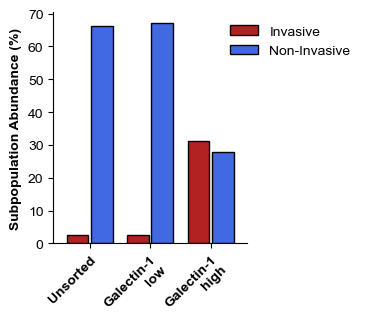

In [50]:
w = 0.9

plt.figure(figsize=(2.5, 3))

plt.bar(
    [0, 2.5, 5],
    [np.sum(df.loc[df['phenotype'] == 'migratory', 'percentage']) for df in [gal1_control, gal1_low, gal1_high]],
    color='firebrick',
    width=w,
    label ='Invasive',
    edgecolor='black'
)

plt.bar(
    [1, 3.5, 6],
    [np.sum(df.loc[df['phenotype'] == 'nonmigratory', 'percentage']) for df in [gal1_control, gal1_low, gal1_high]],
    color='royalblue',
    width=w,
    label = 'Non-Invasive',
    edgecolor='black' 
)

plt.xticks([0.5, 3, 5.5], ['Unsorted', 'Galectin-1\nlow', 'Galectin-1\nhigh'], rotation=45, fontweight='bold', ha='right', va='top', rotation_mode='anchor')

plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
for pos in [ 'top', 'right']:
    plt.gca().spines[pos].set_visible(False)

plt.xlim([-1, 7])
#plt.ylim(0,100)
plt.ylabel('Subpopulation Abundance (%)', fontweight='bold')

plt.legend(frameon=False, loc='best', bbox_to_anchor=(0.85,1))
#plt.savefig('Gal1_sort_abundances.svg', bbox_inches='tight')

([<matplotlib.axis.XTick at 0x7b41a462ca00>,
 [Text(0, 0, 'parent'), Text(1, 0, 'gal1_low'), Text(2, 0, 'gal1_high')])

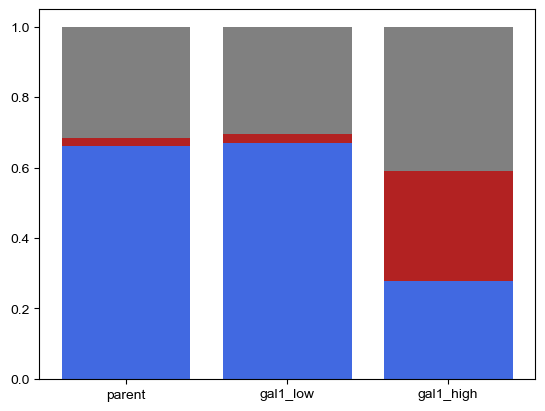

In [51]:
x = [0, 1, 2]

plt.bar(
    x,
    [np.sum(df['proportion']) for df in [gal1_control, gal1_low, gal1_high]],
    color='grey'
)
plt.bar(
    x,
    [np.sum(df.loc[np.isin(df['phenotype'], ['migratory', 'nonmigratory']), 'proportion']) for df in [gal1_control, gal1_low, gal1_high]],
    color='firebrick'
)
plt.bar(
    x,
    [np.sum(df.loc[df['phenotype'] == 'nonmigratory', 'proportion']) for df in [gal1_control, gal1_low, gal1_high]],
    color='royalblue'
)


plt.xticks(x, ['parent', 'gal1_low', 'gal1_high'])

# Analysis of Cell type

In [52]:
ad_hk177 = sc.read_h5ad('HK177_02_processed.h5ad')
ad_hk177 = ad_hk177[:, np.mean(ad_hk177.X != 0., axis=0) > 0.1]

In [53]:
marker_genes = pd.read_csv('MarkerGenes-combined_Neftel.csv')

In [54]:
ad_hk177[ad_hk177.obs['lineage'] == 'TGGCGAGCCGCTGCCACTAG']

View of AnnData object with n_obs × n_vars = 256 × 8873
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublets', 'lineage', 'S_score', 'G2M_score', 'phase', 'cc_difference', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'phenotype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Processing', 'dendrogram_sample', 'hvg', 'leiden', 'leiden_res0_25_colors', 'leiden_res0_5_colors', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'phenotype_colors', 'rank

In [55]:
ad_hk177.obs['non_mi_sorted'] = pd.Categorical(np.where(
    ad_hk177.obs['lineage'] == 'TGGCGAGCCGCTGCCACTAG',
    'TGGCGAGCCGCTGCCACTAG', ''
))

/tmp/ipykernel_251904/20864931.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad_hk177.obs['non_mi_sorted'] = pd.Categorical(np.where(


In [56]:
ad_hk177[ad_hk177.obs['non_mi_sorted'] =='TGGCGAGCCGCTGCCACTAG']

View of AnnData object with n_obs × n_vars = 256 × 8873
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'doublet_score', 'predicted_doublets', 'lineage', 'S_score', 'G2M_score', 'phase', 'cc_difference', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'phenotype', 'non_mi_sorted'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Processing', 'dendrogram_sample', 'hvg', 'leiden', 'leiden_res0_25_colors', 'leiden_res0_5_colors', 'leiden_res1_colors', 'log1p', 'neighbors', 'pca', 'phenoty

In [57]:
HK177_marker_genes_dict = {}
for cell_type in marker_genes.columns:
    # get genes of this cell type
    HK177_genes = marker_genes[cell_type].dropna().to_numpy()
    # remove genes that aren't in our data
    HK177_genes = HK177_genes[[gene in ad_hk177.var_names for gene in HK177_genes]]
    HK177_marker_genes_dict[cell_type] = HK177_genes
    HK177_marker_genes_dict[cell_type] = np.unique(HK177_genes)
HK177_marker_genes_dict

{'MES': array(['ACTN1', 'ADM', 'AKAP12', 'ANGPTL4', 'ANXA1', 'ANXA2', 'APOE',
        'ATF3', 'BNIP3', 'BNIP3L', 'C1R', 'C1S', 'C3', 'CA9', 'CD44',
        'CDKN1A', 'CLIC1', 'CLIC4', 'CTSB', 'DDIT3', 'DNAJB9', 'EFEMP1',
        'EGLN3', 'EMP1', 'EMP3', 'ENO2', 'EPAS1', 'FN1', 'FTL', 'GBE1',
        'GDF15', 'GFPT2', 'GJA1', 'GOLT1B', 'GSN', 'HERPUD1', 'HILPDA',
        'HSPA5', 'HSPA9', 'IFITM3', 'IGFBP7', 'INSIG2', 'LDHA', 'LGALS1',
        'LGALS3', 'MGST1', 'MT1E', 'MT1X', 'MT2A', 'NAMPT', 'NDRG1',
        'NNMT', 'NPC2', 'NRN1', 'P4HA1', 'PFKP', 'PGK1', 'PLOD2', 'PLP2',
        'PPP1R15A', 'PRDX6', 'RCAN1', 'S100A10', 'S100A11', 'S100A16',
        'SERPINE1', 'SERPING1', 'SERTAD1', 'SLC2A1', 'SLC2A3', 'SLC39A14',
        'SLC6A6', 'SOD2', 'SQSTM1', 'TAGLN2', 'TIMP1', 'TNFRSF1A', 'TRAM1',
        'TRIB3', 'TUBA1C', 'UFM1', 'VIM', 'WARS', 'WWTR1', 'XPOT'],
       dtype=object),
 'AC': array(['ANXA5', 'CLU', 'CST3', 'DBI', 'F3', 'GPM6B', 'MT3', 'PMP22',
        'PON2', 'PRCP', 'RAB31

In [58]:
rgg_df_low = sc.get.rank_genes_groups_df(
    sc.tl.rank_genes_groups(
        ad_hk177,
        groupby='lineage',
        groups=['TGGCGAGCCGCTGCCACTAG'],
        reference='rest',
        copy=True,
        method='wilcoxon'
    ),
    group='TGGCGAGCCGCTGCCACTAG'
).set_index('names')
rgg_df_low

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,scores,logfoldchanges,pvals,pvals_adj
names,,,,
BGN,12.500172,3.899896,7.449020e-36,6.609515e-32
PCAT1,12.075048,4.780724,1.430803e-33,6.347755e-30
IGFBP2,11.140446,2.465357,7.971918e-29,2.357828e-25
STAC2,7.928276,1.823434,2.222091e-15,3.943322e-12
DANCR,7.360892,0.972852,1.826856e-13,1.801077e-10
...,...,...,...,...
COX4I1,-6.940628,-0.178379,3.903613e-12,3.463676e-09
MT1E,-7.365868,-0.657121,1.759984e-13,1.801077e-10
MAP1LC3B,-7.500883,-0.316874,6.338942e-14,8.035061e-11


In [59]:
rgg_df_high = sc.get.rank_genes_groups_df(
    sc.tl.rank_genes_groups(
        ad_hk177,
        groupby='lineage',
        groups=['AATAGAGTAGGTCCAGCGTT'],
        reference='rest',
        copy=True,
        method='wilcoxon'
    ),
    group='AATAGAGTAGGTCCAGCGTT'
).set_index('names')
rgg_df_high

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,scores,logfoldchanges,pvals,pvals_adj
names,,,,
COX4I1,9.056953,0.422712,1.341448e-19,1.190267e-15
APRT,8.763465,0.846807,1.893387e-18,8.400013e-15
MT1E,8.065218,1.309318,7.310507e-16,2.162204e-12
CES1,7.911469,2.105332,2.543698e-15,5.642558e-12
MAP1LC3B,7.288991,0.974019,3.122853e-13,3.756798e-10
...,...,...,...,...
COL6A1,-3.958934,-0.148284,7.528497e-05,7.590949e-03
LGALS3BP,-4.760576,-0.338750,1.930412e-06,4.629338e-04
BGN,-6.518926,-3.145334,7.081260e-11,4.833232e-08


In [60]:
for subtype, genes in HK177_marker_genes_dict.items():
    print(subtype, rgg_df_low.loc[np.isin(rgg_df_low.index, genes) & (rgg_df_low['pvals_adj'] <= 0.05), :])

MES            scores  logfoldchanges         pvals     pvals_adj
names                                                        
MGST1    5.352802        0.827093  8.660267e-08  2.260075e-05
PRDX6    3.211210        0.420564  1.321774e-03  3.771094e-02
PLOD2    3.198319        0.459286  1.382312e-03  3.850342e-02
S100A10 -3.182082       -0.057370  1.462202e-03  3.979790e-02
LGALS1  -3.706722       -0.128235  2.099596e-04  1.040766e-02
NAMPT   -3.955598       -0.085538  7.634354e-05  5.032643e-03
CTSB    -4.188266       -0.489469  2.810937e-05  2.309393e-03
S100A11 -4.350983       -0.089239  1.355286e-05  1.336162e-03
GJA1    -4.602740       -1.589889  4.169691e-06  5.210939e-04
IGFBP7  -4.628201       -2.112682  3.688566e-06  4.813037e-04
HERPUD1 -5.158019       -0.592345  2.495762e-07  5.536224e-05
GDF15   -5.589835       -1.889568  2.272854e-08  7.202510e-06
MT1E    -7.365868       -0.657121  1.759984e-13  1.801077e-10
MT2A    -7.797101       -0.534109  6.334520e-15  9.367700e-12
AC  

In [61]:
for subtype, genes in HK177_marker_genes_dict.items():
    print(subtype, rgg_df_high.loc[np.isin(rgg_df_high.index, genes) & (rgg_df_high['pvals_adj'] <= 0.05), :])

MES            scores  logfoldchanges         pvals     pvals_adj
names                                                        
MT1E     8.065218        1.309318  7.310507e-16  2.162204e-12
MT2A     6.346320        0.506991  2.205267e-10  1.304489e-07
NAMPT    4.558157        0.532437  5.160435e-06  9.308127e-04
MT1X     4.554734        0.894488  5.245197e-06  9.308127e-04
EMP1     3.397846        0.768543  6.791876e-04  3.366721e-02
S100A10  3.278491        0.179841  1.043638e-03  4.561674e-02
CD44    -3.690597       -0.621756  2.237287e-04  1.654287e-02
VIM     -3.704239       -0.087507  2.120266e-04  1.621820e-02
AC          scores  logfoldchanges         pvals  pvals_adj
names                                                   
MT3    5.027649        1.458922  4.965285e-07   0.000134
SPARC -3.597762       -0.486777  3.209669e-04   0.020489
OPC          scores  logfoldchanges     pvals  pvals_adj
names                                               
VCAN   4.605799        1.877028  0.

In [62]:
rgg_df_low_comparison = sc.get.rank_genes_groups_df(
    sc.tl.rank_genes_groups(
        ad_hk177,
        groupby='lineage',
        groups=['TGGCGAGCCGCTGCCACTAG'],
        reference='AATAGAGTAGGTCCAGCGTT',
        copy=True,
        method='wilcoxon'
    ),
    group='TGGCGAGCCGCTGCCACTAG'
).set_index('names')
rgg_df_low_comparison

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/get/get.py:69: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,scores,logfoldchanges,pvals,pvals_adj
names,,,,
BGN,13.046037,6.549167,6.694040e-39,5.939622e-35
PCAT1,10.927856,8.290568,8.482887e-28,1.881716e-24
DMKN,9.322323,3.975159,1.138210e-20,1.122149e-17
TGFBI,9.309411,1.415307,1.285427e-20,1.140559e-17
IGFBP2,9.197768,1.499230,3.654606e-20,2.947938e-17
...,...,...,...,...
TM4SF1,-9.764085,-1.643863,1.605551e-22,2.035150e-19
MT2A,-10.108634,-0.963710,5.058463e-24,7.480624e-21
MAP1LC3B,-10.863807,-1.189263,1.714494e-27,3.042542e-24


In [63]:
for subtype, genes in HK177_marker_genes_dict.items():
    print(subtype, rgg_df_low_comparison.loc[np.isin(rgg_df_low_comparison.index, genes) & (rgg_df_low_comparison['pvals_adj'] <= 0.05), :])

MES             scores  logfoldchanges         pvals     pvals_adj
names                                                         
MGST1     4.184463        0.520904  2.858409e-05  2.326850e-03
PLOD2     3.969531        0.398366  7.201417e-05  5.324848e-03
GSN      -3.597641       -0.487980  3.211167e-04  1.835360e-02
EMP1     -3.849028       -0.895602  1.185877e-04  8.156808e-03
S100A11  -4.260411       -0.227896  2.040515e-05  1.724333e-03
S100A10  -4.649263       -0.218542  3.331235e-06  3.649142e-04
MT1X     -5.024697       -1.029326  5.042269e-07  7.101596e-05
GJA1     -5.141657       -2.163514  2.723262e-07  4.166122e-05
GDF15    -5.184694       -2.262760  2.163700e-07  3.428306e-05
HERPUD1  -5.588229       -1.124961  2.293969e-08  5.088597e-06
NAMPT    -5.931259       -0.568291  3.006199e-09  7.621144e-07
MT2A    -10.108634       -0.963710  5.058463e-24  7.480624e-21
MT1E    -11.071144       -1.814503  1.731755e-28  5.121954e-25
AC          scores  logfoldchanges     pvals  pvals

In [64]:
genes_display = ['MT1E','MT2A','NAMPT','HERPUD1', 'MT1X','LGALS1','GDF15','APOD','PGRMC1','FABP5']

In [65]:
HK177_marker_genes_dict_subset = {
    cell_type:HK177_marker_genes_dict[cell_type][ad_hk177[:, HK177_marker_genes_dict[cell_type]].layers['norm_counts'].mean(axis=0).A1.argsort()][:-5-1:-1] for cell_type in HK177_marker_genes_dict.keys()
}
HK177_marker_genes_dict_subset

{'MES': array(['FTL', 'VIM', 'LGALS1', 'MT2A', 'LDHA'], dtype=object),
 'AC': array(['CST3', 'ANXA5', 'S100A16', 'DBI', 'PON2'], dtype=object),
 'OPC': array(['DBI', 'PGRMC1', 'GPM6B', 'RAB31', 'FABP5'], dtype=object),
 'NPC': array(['TUBA1A', 'MARCKSL1', 'MAP1B', 'TUBB3', 'STMN1'], dtype=object)}

/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/stor/home/tms4478/miniconda3/envs/scrna/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be igno

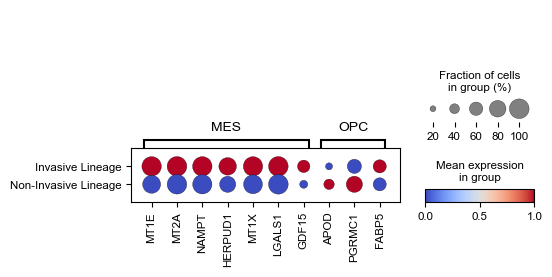

In [66]:
adata_subset = ad_hk177[ad_hk177.obs['lineage'].isin(['TGGCGAGCCGCTGCCACTAG', 'AATAGAGTAGGTCCAGCGTT'])].copy()

adata_subset.obs['lineage'] = adata_subset.obs['lineage'].cat.rename_categories({
    'TGGCGAGCCGCTGCCACTAG': 'Non-Invasive Lineage',
    'AATAGAGTAGGTCCAGCGTT': 'Invasive Lineage'
})

sc.pl.dotplot(
    adata_subset,
    var_names = {
        'MES':['MT1E','MT2A','NAMPT','HERPUD1', 'MT1X','LGALS1','GDF15'],
        'OPC':['APOD','PGRMC1','FABP5']
    },
    groupby='lineage',
    standard_scale='var',
    cmap='coolwarm',
    #save = 'sortedcell_celltype_genes.svg'
)